#**Image Segmentation**

---


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls "/content/drive/MyDrive/Colab Notebooks/Segmentattion_dataset"

annotations.tar.gz  images.tar.gz


In [3]:
!tar -xvzf "/content/drive/MyDrive/Colab Notebooks/Segmentattion_dataset/images.tar.gz"
!tar -xvzf "/content/drive/MyDrive/Colab Notebooks/Segmentattion_dataset/annotations.tar.gz"


Streaming output truncated to the last 5000 lines.
annotations/trimaps/._pomeranian_180.png
annotations/trimaps/pomeranian_180.png
annotations/trimaps/._pomeranian_181.png
annotations/trimaps/pomeranian_181.png
annotations/trimaps/._pomeranian_182.png
annotations/trimaps/pomeranian_182.png
annotations/trimaps/._pomeranian_183.png
annotations/trimaps/pomeranian_183.png
annotations/trimaps/._pomeranian_184.png
annotations/trimaps/pomeranian_184.png
annotations/trimaps/._pomeranian_185.png
annotations/trimaps/pomeranian_185.png
annotations/trimaps/._pomeranian_186.png
annotations/trimaps/pomeranian_186.png
annotations/trimaps/._pomeranian_187.png
annotations/trimaps/pomeranian_187.png
annotations/trimaps/._pomeranian_188.png
annotations/trimaps/pomeranian_188.png
annotations/trimaps/._pomeranian_189.png
annotations/trimaps/pomeranian_189.png
annotations/trimaps/._pomeranian_19.png
annotations/trimaps/pomeranian_19.png
annotations/trimaps/._pomeranian_190.png
annotations/trimaps/pomeranian

In [4]:
!ls "/content/drive/MyDrive/Colab Notebooks/Segmentattion_dataset"
!ls "/content/drive/MyDrive/Colab Notebooks/Segmentattion_dataset/images" | head
!ls "/content/drive/MyDrive/Colab Notebooks/Segmentattion_dataset/annotations/trimaps" | head


annotations.tar.gz  images.tar.gz
ls: cannot access '/content/drive/MyDrive/Colab Notebooks/Segmentattion_dataset/images': No such file or directory
ls: cannot access '/content/drive/MyDrive/Colab Notebooks/Segmentattion_dataset/annotations/trimaps': No such file or directory


(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

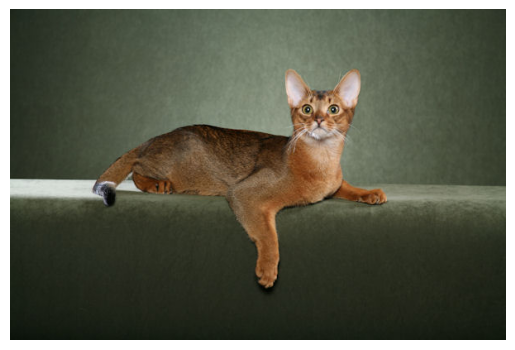

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/images/Abyssinian_1.jpg")
plt.imshow(img)
plt.axis("off")


array([1, 2, 3], dtype=uint8)

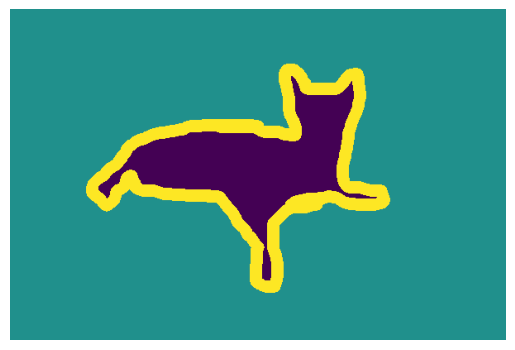

In [6]:
import numpy as np
mask = Image.open("/content/annotations/trimaps/Abyssinian_1.png")
plt.imshow(mask)
plt.axis("off")
np.unique(np.array(mask))

In [7]:
import os
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode


class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, size=(256,256)):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.size = size
        self.ignore_value = 255

        # Only allow valid image extensions
        valid_extensions = (".jpg", ".jpeg", ".png")

        all_files = os.listdir(image_dir)
        valid_images = []

        for fname in all_files:
            # Skip hidden files
            if fname.startswith("._"):
                continue

            # Skip non-image files (e.g., .mat)
            if not fname.lower().endswith(valid_extensions):
                continue

            # Ensure matching mask exists
            mask_name = os.path.splitext(fname)[0] + ".png"
            mask_path = os.path.join(mask_dir, mask_name)

            if os.path.exists(mask_path):
                valid_images.append(fname)

        self.images = sorted(valid_images)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        fname = self.images[idx]

        image = Image.open(os.path.join(self.image_dir, fname)).convert("RGB")
        mask  = Image.open(
            os.path.join(
                self.mask_dir,
                os.path.splitext(fname)[0] + ".png"
            )
        ).convert("L")

        # Resize
        image = TF.resize(image, self.size,
                          interpolation=InterpolationMode.BILINEAR)

        mask  = TF.resize(mask, self.size,
                          interpolation=InterpolationMode.NEAREST)

        # Remap mask
        mask_np = np.array(mask)

        remapped = np.full(mask_np.shape,
                           self.ignore_value,
                           dtype=np.uint8)

        remapped[mask_np == 1] = 1
        remapped[mask_np == 2] = 0

        # Convert to tensors
        image = TF.to_tensor(image)
        mask  = torch.from_numpy(remapped).long()

        return image, mask

In [8]:
dataset = SegmentationDataset(
    image_dir="/content/images",
    mask_dir="/content/annotations/trimaps"
)

img, mask = dataset[0]

print(img.shape, img.dtype)
print(mask.shape, mask.dtype)
print(torch.unique(mask))


torch.Size([3, 256, 256]) torch.float32
torch.Size([256, 256]) torch.int64
tensor([  0,   1, 255])


In [9]:
dataset = SegmentationDataset(
    image_dir="/content/images",
    mask_dir="/content/annotations/trimaps"
)

print("Dataset length:", len(dataset))

img, mask = dataset[0]
print(type(img), type(mask))


Dataset length: 7390
<class 'torch.Tensor'> <class 'torch.Tensor'>


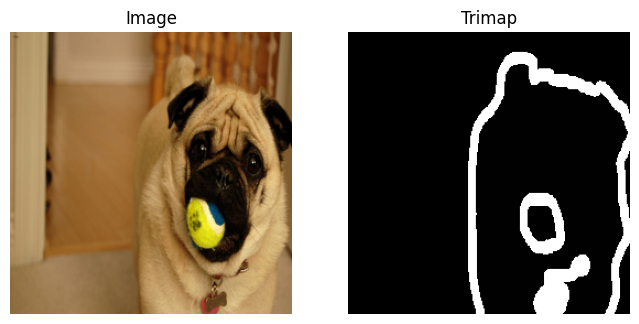

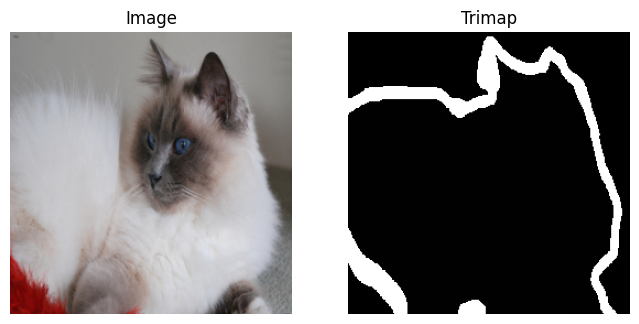

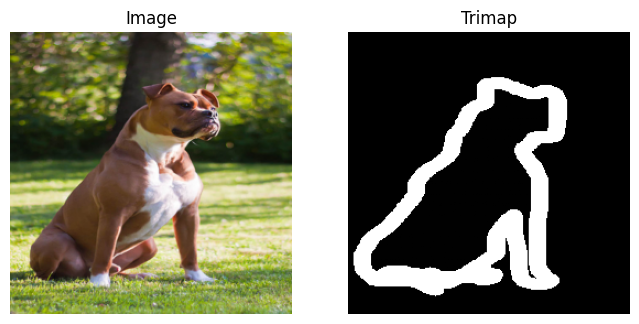

In [10]:
import random
import matplotlib.pyplot as plt

# pick 3 random samples
indices = random.sample(range(len(dataset)), 3)

for idx in indices:
    image, mask = dataset[idx]

    plt.figure(figsize=(8, 4))

    # image
    plt.subplot(1, 2, 1)
    plt.imshow(image.permute(1, 2, 0).numpy()) # Fix: transpose dimensions and convert to numpy
    plt.title("Image")
    plt.axis("off")

    # mask
    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Trimap")
    plt.axis("off")

    plt.show()

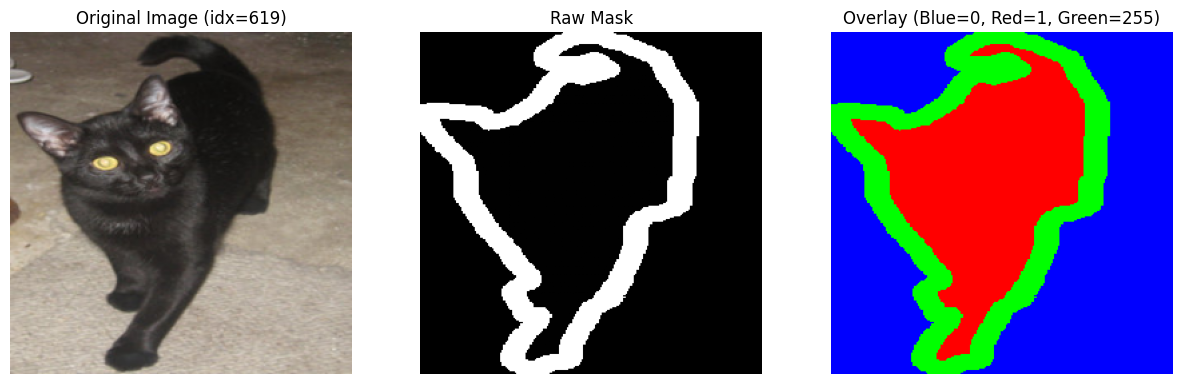

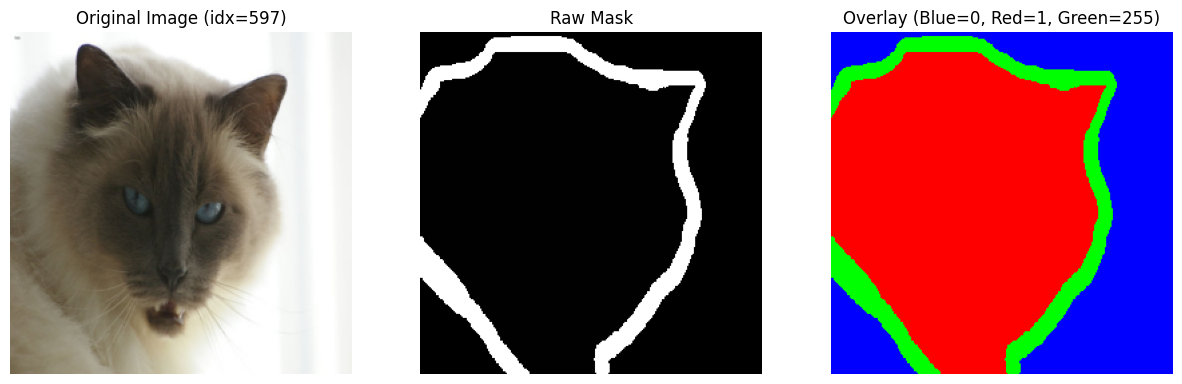

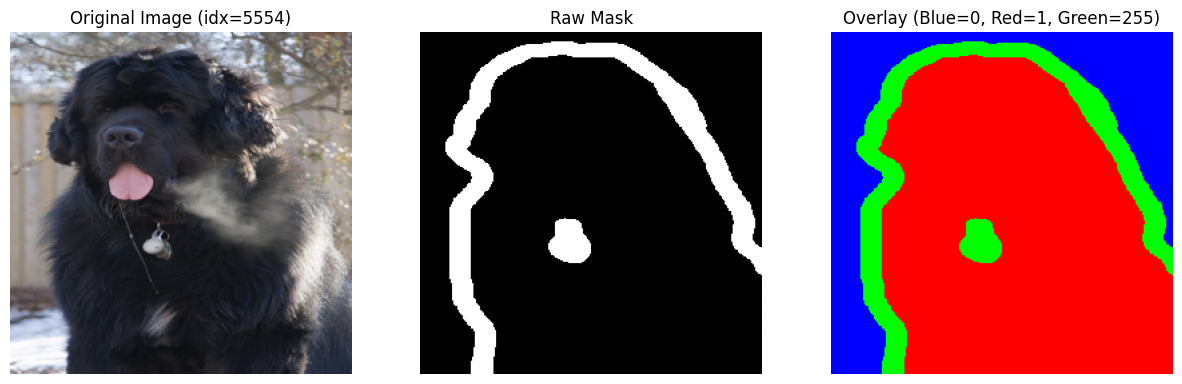

In [11]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import random

def visualize_random_samples(dataset, num_samples=3):
    indices = random.sample(range(len(dataset)), num_samples)

    for idx in indices:
        image, mask = dataset[idx]

        image_np = image.permute(1, 2, 0).numpy()
        mask_np = mask.numpy()

        # Create blank overlay (black background)
        overlay = np.zeros_like(image_np)

        # Define regions
        background = mask_np == 0
        foreground = mask_np == 1
        boundary = mask_np == 255

        # Assign clear distinct colors
        overlay[background] = [0, 0, 1]   # BLUE → 0 (background)
        overlay[foreground] = [1, 0, 0]   # RED → 1 (pet)
        overlay[boundary]   = [0, 1, 0]   # GREEN → 255 (boundary)

        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(image_np)
        plt.title(f"Original Image (idx={idx})")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(mask_np, cmap="gray")
        plt.title("Raw Mask")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(overlay)
        plt.title("Overlay (Blue=0, Red=1, Green=255)")
        plt.axis("off")

        plt.show()

# Run it
visualize_random_samples(dataset, num_samples=3)

In [12]:
from torch.utils.data import DataLoader
import torch

def compute_mean_std(dataset):
    loader = DataLoader(dataset, batch_size=16, shuffle=False)

    channel_sum = torch.zeros(3)
    channel_sq_sum = torch.zeros(3)
    total_pixels = 0

    for images, _ in loader:
        # images: (B, C, H, W)
        b, c, h, w = images.shape
        num_pixels = b * h * w

        channel_sum += images.sum(dim=[0, 2, 3])
        channel_sq_sum += (images ** 2).sum(dim=[0, 2, 3])

        total_pixels += num_pixels

    mean = channel_sum / total_pixels
    std = torch.sqrt(channel_sq_sum / total_pixels - mean ** 2)

    return mean, std

In [13]:
full_dataset = SegmentationDataset("/content/images",
                                    "/content/annotations/trimaps")

mean, std = compute_mean_std(full_dataset)

print("Mean:", mean)
print("Std:", std)

Mean: tensor([0.4811, 0.4492, 0.3957])
Std: tensor([0.2650, 0.2602, 0.2686])


In [14]:
from torch.utils.data import random_split
import torch

train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=generator
)

In [15]:
import random
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
import torch

class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, mean, std):
        self.dataset = dataset
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        # ----- Spatial Aug -----
        if random.random() < 0.5:
            image = TF.hflip(image)
            mask  = TF.hflip(mask)

        angle = random.uniform(-10, 10)

        image = TF.rotate(
            image,
            angle,
            interpolation=InterpolationMode.BILINEAR
        )

        mask = TF.rotate(
            mask.unsqueeze(0),  # (1, H, W)
            angle,
            interpolation=InterpolationMode.NEAREST,
            fill=255
        ).squeeze(0)  # Back to (H, W)

        # ----- Color Aug (image only) -----
        image = TF.adjust_brightness(
            image,
            1 + random.uniform(-0.1, 0.1)
        )

        image = TF.adjust_contrast(
            image,
            1 + random.uniform(-0.1, 0.1)
        )

        # ----- Normalize -----
        image = TF.normalize(image, self.mean, self.std)

        return image, mask.long()

In [16]:
train_dataset = AugmentedDataset(train_dataset, mean, std)

# Validation: only normalization
class NormalizedDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, mean, std):
        self.dataset = dataset
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]
        image = TF.normalize(image, self.mean, self.std)
        return image, mask

val_dataset = NormalizedDataset(val_dataset, mean, std)

In [17]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [18]:
for i in range(5):
    img, mask = train_dataset[i]
    print(torch.unique(mask))

tensor([  0,   1, 255])
tensor([  0,   1, 255])
tensor([  0,   1, 255])
tensor([  0,   1, 255])
tensor([  0,   1, 255])


In [19]:
import torch
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super(ConvBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu2 = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        return x

In [20]:
class Encoder(nn.Module):
  def __init__(self,in_channels,out_channels):
    super().__init__()
    self.conv=ConvBlock(in_channels,out_channels)
    self.maxpool=nn.MaxPool2d(2)

  def forward(self,x):
    skip=self.conv(x)
    x=self.maxpool(skip)
    return x,skip

In [21]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.upconv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = ConvBlock(in_channels, out_channels)

    def forward(self, x, skip):
        x = self.upconv(x)
        x = torch.cat([skip, x], dim=1)
        x = self.conv(x)
        return x

In [22]:
class PaddedU_Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.enc1=Encoder(3,64)
    self.enc2=Encoder(64,128)
    self.enc3=Encoder(128,256)
    self.enc4=Encoder(256,512)
    self.bottleneck=ConvBlock(512,1024)
    self.dec1=DecoderBlock(1024,512)
    self.dec2=DecoderBlock(512,256)
    self.dec3=DecoderBlock(256,128)
    self.dec4=DecoderBlock(128,64)
    self.final=nn.Conv2d(64,1,kernel_size=1)
  def forward(self,x):
    x,skip1=self.enc1(x)
    x,skip2=self.enc2(x)
    x,skip3=self.enc3(x)
    x,skip4=self.enc4(x)
    x=self.bottleneck(x)
    x=self.dec1(x,skip4)
    x=self.dec2(x,skip3)
    x=self.dec3(x,skip2)
    x=self.dec4(x,skip1)
    x=self.final(x)
    return x


In [23]:
model = PaddedU_Net()
x = torch.randn(1, 3, 256, 256)
y = model(x)
print(y.shape)

torch.Size([1, 1, 256, 256])


In [24]:
print(sum(p.numel() for p in model.parameters() if p.requires_grad))

31043521


In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BCEDiceLoss(nn.Module):
    def __init__(self, ignore_index=255, smooth=1e-7):
        super().__init__()
        self.ignore_index = ignore_index
        self.smooth = smooth

    def forward(self, logits, targets):
        logits = logits.squeeze(1)  # (B, H, W)

        # Create valid mask
        valid_mask = (targets != self.ignore_index)

        # Filter valid pixels
        logits = logits[valid_mask]
        targets = targets[valid_mask].float()

        # ----- BCE -----
        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction='mean'
        )

        # ----- Dice -----
        probs = torch.sigmoid(logits)

        intersection = (probs * targets).sum()
        union = probs.sum() + targets.sum()

        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        dice_loss = 1 - dice

        return bce + dice_loss

In [26]:
loss_fn = BCEDiceLoss()
images, masks = next(iter(train_loader))
logits = model(images)
loss = loss_fn(logits, masks)
print("Loss:", loss.item())

Loss: 1.2583677768707275


In [27]:
!pip install thop -q

In [28]:
from thop import profile
model=PaddedU_Net()
x = torch.randn(1, 3, 256, 256)
macs,params=profile(model,inputs=(x,))
print(macs,params)

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.ConvTranspose2d'>.
54737764352.0 31043521.0


In [29]:
model=PaddedU_Net()
for name,module in model.named_children():
  print(name,sum(p.numel() for p in module.parameters()))

enc1 38976
enc2 221952
enc3 886272
enc4 3542016
bottleneck 14161920
dec1 9178624
dec2 2295552
dec3 574336
dec4 143808
final 65


In [30]:
import torch
import time

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = PaddedU_Net().to(device)
model.eval()

x = torch.randn(1, 3, 256, 256).to(device)

with torch.no_grad():
    # Warmup (important for GPU)
    for _ in range(10):
        model(x)

    if device.type == "cuda":
        torch.cuda.synchronize()

    total_time = 0.0

    for _ in range(50):
        start = time.time()

        model(x)

        if device.type == "cuda":
            torch.cuda.synchronize()

        end = time.time()
        total_time += (end - start)

avg_inference_time = total_time / 50
print(f"Avg inference time: {avg_inference_time * 1000:.2f} ms")

Using device: cuda
Avg inference time: 23.06 ms


In [31]:
def compute_batch_statistics(logits, targets, ignore_index=255, threshold=0.5):

    # Remove channel dim
    logits = logits.squeeze(1)

    # Apply sigmoid to get probabilities
    probs = torch.sigmoid(logits)

    # Binary prediction
    preds = (probs > threshold).long()

    # Mask out ignore pixels
    valid_mask = (targets != ignore_index)

    preds = preds[valid_mask]
    targets = targets[valid_mask]

    # Compute statistics
    tp = ((preds == 1) & (targets == 1)).sum().item()
    fp = ((preds == 1) & (targets == 0)).sum().item()
    fn = ((preds == 0) & (targets == 1)).sum().item()

    return tp, fp, fn

In [34]:
import torch
import torch.optim as optim
import numpy as np
import random
import time
import csv
import json

# ===============================
# 0. Device Setup
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===============================
# 1. Seed Control
# ===============================
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# ===============================
# 2. Metric Tracker
# ===============================
class MetricTracker:
    def __init__(self):
        self.reset()

    def reset(self):
        self.tp = 0
        self.fp = 0
        self.fn = 0
        self.loss_sum = 0
        self.count = 0

    def update(self, tp, fp, fn, loss, batch_size):
        self.tp += tp
        self.fp += fp
        self.fn += fn
        self.loss_sum += loss * batch_size
        self.count += batch_size

    def compute(self):
        eps = 1e-7
        dice = (2 * self.tp) / (2 * self.tp + self.fp + self.fn + eps)
        loss = self.loss_sum / self.count
        return dice, loss

# ===============================
# 3. Train One Epoch
# ===============================
def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    tracker = MetricTracker()

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = loss_fn(logits, masks)

        loss.backward()
        optimizer.step()

        tp, fp, fn = compute_batch_statistics(logits, masks)
        tracker.update(tp, fp, fn, loss.item(), images.size(0))

    return tracker.compute()

# ===============================
# 4. Validate One Epoch
# ===============================
def validate_one_epoch(model, loader, loss_fn):
    model.eval()
    tracker = MetricTracker()

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            loss = loss_fn(logits, masks)

            tp, fp, fn = compute_batch_statistics(logits, masks)
            tracker.update(tp, fp, fn, loss.item(), images.size(0))

    return tracker.compute()

# ===============================
# 5. Training Driver
# ===============================
def train_model(seed):

    print(f"\n========== Seed {seed} ==========")

    set_seed(seed)

    model = PaddedU_Net().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5
    )
    loss_fn = BCEDiceLoss()

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_dice": [],
        "val_dice": [],
        "epoch_time": []
    }

    best_val_dice = 0
    best_epoch = 0

    log_file = f"training_log_seed_{seed}.csv"

    # Create CSV header
    with open(log_file, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "epoch",
            "train_dice",
            "val_dice",
            "train_loss",
            "val_loss",
            "epoch_time"
        ])

    for epoch in range(20):   # LOCKED TO 20 EPOCHS

        start_time = time.time()

        train_dice, train_loss = train_one_epoch(
            model, train_loader, optimizer, loss_fn
        )

        val_dice, val_loss = validate_one_epoch(
            model, val_loader, loss_fn
        )

        scheduler.step(val_dice)

        if device.type == "cuda":
            torch.cuda.synchronize()

        epoch_time = time.time() - start_time

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_dice"].append(train_dice)
        history["val_dice"].append(val_dice)
        history["epoch_time"].append(epoch_time)

        # Save CSV row
        with open(log_file, "a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([
                epoch+1,
                train_dice,
                val_dice,
                train_loss,
                val_loss,
                epoch_time
            ])

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            best_epoch = epoch
            torch.save(model.state_dict(), f"best_model_seed_{seed}.pt")

        print(f"Epoch {epoch+1:02d} | "
              f"Train Dice: {train_dice:.4f} | "
              f"Val Dice: {val_dice:.4f} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Time: {epoch_time:.2f}s")

    print(f"\nBest Val Dice: {best_val_dice:.4f} at epoch {best_epoch+1}")

    # Save JSON summary
    summary = {
        "seed": seed,
        "best_val_dice": float(best_val_dice),
        "best_epoch": int(best_epoch + 1),
        "mean_train_dice": float(np.mean(history["train_dice"])),
        "mean_val_dice": float(np.mean(history["val_dice"])),
        "mean_epoch_time": float(np.mean(history["epoch_time"]))
    }

    with open(f"summary_seed_{seed}.json", "w") as f:
        json.dump(summary, f, indent=4)

    return history, best_val_dice

# ===============================
# 6. Run 2 Seeds ONLY
# ===============================
all_results = []

for seed in [42, 123]:
    history, best_val = train_model(seed)

    all_results.append({
        "seed": seed,
        "best_val_dice": best_val,
        "history": history
    })

# ===============================
# 7. Final Mean + Std
# ===============================
best_scores = [r["best_val_dice"] for r in all_results]

print("\n====== FINAL RESULTS ======")
print("Best Dice per seed:", best_scores)
print("Mean Dice:", np.mean(best_scores))
print("Std Dice:", np.std(best_scores))

Using device: cuda

========== Seed 42 ==========
Epoch 01 | Train Dice: 0.6920 | Val Dice: 0.5624 | Train Loss: 0.8585 | Val Loss: 1.0383 | Time: 493.45s
Epoch 02 | Train Dice: 0.7343 | Val Dice: 0.7659 | Train Loss: 0.7651 | Val Loss: 0.6997 | Time: 488.77s
Epoch 03 | Train Dice: 0.7890 | Val Dice: 0.7800 | Train Loss: 0.6310 | Val Loss: 0.6023 | Time: 491.23s
Epoch 04 | Train Dice: 0.8211 | Val Dice: 0.8394 | Train Loss: 0.5430 | Val Loss: 0.4725 | Time: 492.12s
Epoch 05 | Train Dice: 0.8538 | Val Dice: 0.8768 | Train Loss: 0.4516 | Val Loss: 0.3852 | Time: 493.32s
Epoch 06 | Train Dice: 0.8716 | Val Dice: 0.8945 | Train Loss: 0.4010 | Val Loss: 0.3244 | Time: 491.99s
Epoch 07 | Train Dice: 0.8862 | Val Dice: 0.8973 | Train Loss: 0.3604 | Val Loss: 0.3154 | Time: 493.87s
Epoch 08 | Train Dice: 0.8978 | Val Dice: 0.9010 | Train Loss: 0.3275 | Val Loss: 0.3038 | Time: 492.36s
Epoch 09 | Train Dice: 0.9024 | Val Dice: 0.9034 | Train Loss: 0.3141 | Val Loss: 0.2977 | Time: 491.06s
Epoch